langgraph是底层编排框架、Agent运行时，有点像AI版的工作流

langchain是高层的开发框架，底层是langgraph。

graph的构成三要素：
1. 状态（state）：一个共享的数据包，可以流向所有的节点
2. 节点（node）：干活的的人，一段代码，执行逻辑，接收状态
3. 边（edge）：连接起节点和节点的关系
4. stateGraph：把状态、节点、边组装起来





In [5]:
import numbers
import operator
from traceback import print_tb

from langgraph.graph import StateGraph,START,END

from typing import TypedDict


# 定义状态
class State(TypedDict):
    node: list[str]
    cur_id: str


# 定义节点,每个节点是一个函数
def node1(state:State):
    state['node'] = ['a', 'b']
    state['cur_id'] = 'node1'
    return state


def node2(state:State):
    state['node'] = ['c', 'd']
    state['cur_id'] = 'node2'
    return state

# 构成图
graph = StateGraph(State)

graph.add_node("node_1",node1)
graph.add_node("node_2",node2)

# 边，串联节点
graph.add_edge(START,"node_1")
graph.add_edge("node_1","node_2")
graph.add_edge("node_2",END)

graph = graph.compile()

result = graph.invoke({
    "node":[],
    "cur_id":"default"
})

print(result)

{'node': ['c', 'd'], 'cur_id': 'node2'}


定义reduce

In [10]:


from typing import Annotated


class State(TypedDict):
    #  表示 numbers 这个字段 使用operator.add 进行合并
    numbers: Annotated[list[int],operator.add]


def node1(state:State):
    print('执行了节点1')
    return {
        "numbers":[3,4]
    }

def node2(state:State):
    print('执行了节点2')
    return {
        "numbers":[5,6]
    }


build = StateGraph(state_schema=State)

build.add_node("node_1",node1)
build.add_node("node_2",node2)
build.add_edge(START,"node_1")
build.add_edge("node_1","node_2")
build.add_edge("node_2",END)

graph = build.compile()

graph.invoke({
    "numbers":[1,2]
})



执行了节点1
执行了节点2


{'numbers': [1, 2, 3, 4, 5, 6]}

========== 开始执行 Graph ==========
初始 State： {'question': '我下单的 Mac Book Pro 订单 发货了没有？'}

========== Node 1：解析问题 ==========
读取到的问题： 我下单的 Mac Book Pro 订单 发货了没有？
本节点返回的更新： {'question': '我下单的 Mac Book Pro 订单 发货了没有？'}

========== Node 2：识别意图 ==========
当前问题： 我下单的 Mac Book Pro 订单 发货了没有？
识别出的意图： order
本节点返回的更新： {'intent': 'order'}

========== Node 3：选择工具 ==========
当前意图： order
选择的工具： order_tool
本节点返回的更新： {'tool_name': 'order_tool'}

========== Node 4：执行工具 ==========
准备执行工具： order_tool
工具执行结果： 订单查询成功，订单状态为已发货。
本节点返回的更新： {'tool_result': '订单查询成功，订单状态为已发货。'}

========== Node 5：生成回答 ==========
用户问题： 我下单的 Mac Book Pro 订单 发货了没有？
用户意图： order
工具结果： 订单查询成功，订单状态为已发货。
最终回答： 你的问题是：我下单的 Mac Book Pro 订单 发货了没有？
识别意图：order
查询结果：订单查询成功，订单状态为已发货。
本节点返回的更新： {'answer': '你的问题是：我下单的 Mac Book Pro 订单 发货了没有？\n识别意图：order\n查询结果：订单查询成功，订单状态为已发货。'}

========== Graph 执行结束 ==========
最终 State：
question = 我下单的 Mac Book Pro 订单 发货了没有？
intent = order
tool_name = order_tool
tool_result = 订单查询成功，订单状态为已发货。
answer = 你的问题是：我下单的 Mac B

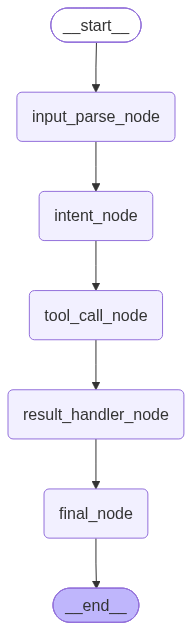

In [23]:


# class State(TypedDict):
#     messages: Annotated[list[int],operator.add]

class State(TypedDict):
    question: str
    intent: str
    tool_name: str
    tool_result: str
    answer: str


# 输入解析节点
def parse_question(state:State):
    print("\n========== Node 1：解析问题 ==========")

    # 读取 State 中的 question
    question = state["question"].strip()

    print("读取到的问题：", question)

    # 返回需要更新的字段
    update = {
        "question": question
    }

    print("本节点返回的更新：", update)

    return update


# 意图识别节点
def identify_intent(state:State):
    print("\n========== Node 2：识别意图 ==========")

    # 读取上一个节点传递过来的 question
    question = state["question"]

    print("当前问题：", question)

    # 使用简单的关键词判断，模拟意图识别
    if "天气" in question:
        intent = "weather"
    elif "订单" in question:
        intent = "order"
    else:
        intent = "general"

    update = {
        "intent": intent
    }

    print("识别出的意图：", intent)
    print("本节点返回的更新：", update)

    return update

# 工具调用节点
def select_tool(state:State):
    print("\n========== Node 3：选择工具 ==========")

    # 读取上一个节点生成的 intent
    intent = state["intent"]

    print("当前意图：", intent)

    if intent == "weather":
        tool_name = "weather_tool"
    elif intent == "order":
        tool_name = "order_tool"
    else:
        tool_name = "knowledge_tool"

    update = {
        "tool_name": tool_name
    }

    print("选择的工具：", tool_name)
    print("本节点返回的更新：", update)

    return update


# 结果处理节点
def call_tool(state:State):
    print("\n========== Node 4：执行工具 ==========")

    # 读取上一个节点生成的 tool_name
    tool_name = state["tool_name"]
    question = state["question"]

    print("准备执行工具：", tool_name)

    # 模拟工具执行，不调用真实 API
    if tool_name == "weather_tool":
        tool_result = "北京今天晴天，气温 25℃。"
    elif tool_name == "order_tool":
        tool_result = "订单查询成功，订单状态为已发货。"
    else:
        tool_result = f"已收到问题：{question}，暂无外部工具查询结果。"

    update = {
        "tool_result": tool_result
    }

    print("工具执行结果：", tool_result)
    print("本节点返回的更新：", update)

    return update

# 最终回答
def generate_answer(state:State):
    print("\n========== Node 5：生成回答 ==========")

    # 读取前面节点积累到 State 中的数据
    question = state["question"]
    intent = state["intent"]
    tool_result = state["tool_result"]

    print("用户问题：", question)
    print("用户意图：", intent)
    print("工具结果：", tool_result)

    answer = (
        f"你的问题是：{question}\n"
        f"识别意图：{intent}\n"
        f"查询结果：{tool_result}"
    )

    update = {
        "answer": answer
    }

    print("最终回答：", answer)
    print("本节点返回的更新：", update)

    return update


build = StateGraph(state_schema=State)
build.add_node("input_parse_node",parse_question)
build.add_node("intent_node",identify_intent)
build.add_node("tool_call_node",select_tool)
build.add_node("result_handler_node",call_tool)
build.add_node("final_node",generate_answer)

build.add_edge(START,"input_parse_node")
build.add_edge("input_parse_node","intent_node")
build.add_edge("intent_node","tool_call_node")
build.add_edge("tool_call_node","result_handler_node")
build.add_edge("result_handler_node","final_node")
build.add_edge(START,"input_parse_node")
build.add_edge("final_node",END)

graph = build.compile()

# initial_state: State = {
#     "question": "北京今天天气怎么样？"
# }

initial_state: State = {
    "question": "我下单的 Mac Book Pro 订单 发货了没有？"
}

print("========== 开始执行 Graph ==========")
print("初始 State：", initial_state)

result = graph.invoke(initial_state)

print("\n========== Graph 执行结束 ==========")
print("最终 State：")

for key, value in result.items():
    print(f"{key} = {value}")

# print(graph.invoke({
#     "messages":[]
# }))

display(graph)
